# Multi-Omics WGCNA Tutorial

## Weighted Gene Co-expression Network Analysis on Combined Expression + Genotype Data

This notebook demonstrates WGCNA applied to a **multi-omics dataset** combining:
- **Gene expression data** (RNA-seq counts) - 100 genes
- **Genotype data** (SNP dosage: 0, 1, 2) - 50 SNPs

### Dataset Overview
- 300 samples (200 ASD cases, 100 controls)
- 100 genes from bulk RNA-seq
- 50 SNPs from WGS data (values 0, 1, 2 = number of minor alleles)
- Clinical covariates: Age, Sex, IQ, ADOS Score

### WGCNA Steps
1. Load and preprocess data (expression + genotypes)
2. Merge into combined feature matrix
3. Compute feature-feature similarity
4. Choose soft-thresholding power
5. Build adjacency and TOM matrices
6. Cluster features into modules
7. Calculate module eigengenes
8. Relate modules to traits

---
## Step 1: Setup and Data Loading

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)
%matplotlib inline

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# =============================================================================
# LOAD DATA
# =============================================================================
DATA_DIR = "../data/ASD_dataset/"

# Load all datasets
expression = pd.read_csv(f"{DATA_DIR}ASD_expression.csv").set_index('sample')
genotypes = pd.read_csv(f"{DATA_DIR}ASD_genotypes.csv").set_index('sample')
covariates = pd.read_csv(f"{DATA_DIR}ASD_covariates.csv").set_index('sample')

print("Data shapes:")
print(f"  Expression: {expression.shape[0]} samples x {expression.shape[1]} genes")
print(f"  Genotypes:  {genotypes.shape[0]} samples x {genotypes.shape[1]} SNPs")
print(f"  Covariates: {covariates.shape[0]} samples x {covariates.shape[1]} variables")

Data shapes:
  Expression: 300 samples x 100 genes
  Genotypes:  300 samples x 50 SNPs
  Covariates: 300 samples x 28 variables


---
## Step 2: Preprocessing

To combine expression and genotype data for WGCNA, we need to:
1. **Expression**: Log-transform (log2(x+1)) then z-score standardize
2. **Genotypes**: Z-score standardize (they're already 0/1/2 coded)

This puts both data types on comparable scales for correlation analysis.

In [3]:
# =============================================================================
# PREPROCESS EXPRESSION DATA
# =============================================================================
print("Preprocessing Expression Data")
print("="*50)

# Log-transform count data: log2(x + 1)
#  RNA-seq counts range from 0 to thousands/millions
# A few highly-expressed genes dominate the variance
# Without log, z-score standardization would be distorted by outliers
expr_log = np.log2(expression + 1) 
print(f"Applied log2(x+1) transformation")

# Z-score standardize (mean=0, std=1 per gene)
scaler_expr = StandardScaler()
expr_scaled = pd.DataFrame(
    scaler_expr.fit_transform(expr_log),
    index=expression.index,
    columns=expression.columns
)
print(f"Z-score standardized: mean={expr_scaled.mean().mean():.4f}, std={expr_scaled.std().mean():.4f}")
print(f"Expression shape: {expr_scaled.shape}")

Preprocessing Expression Data
Applied log2(x+1) transformation
Z-score standardized: mean=-0.0000, std=1.0017
Expression shape: (300, 100)


In [4]:
# =============================================================================
# PREPROCESS GENOTYPE DATA
# =============================================================================
print("Preprocessing Genotype Data")
print("="*50)

# Show original genotype distribution
print(f"Original genotype values: {sorted(genotypes.values.flatten())[:10]}... (0=hom ref, 1=het, 2=hom alt)")

# Z-score standardize genotypes
scaler_geno = StandardScaler()
geno_scaled = pd.DataFrame(
    scaler_geno.fit_transform(genotypes),
    index=genotypes.index,
    columns=genotypes.columns
)
print(f"Z-score standardized: mean={geno_scaled.mean().mean():.4f}, std={geno_scaled.std().mean():.4f}")
print(f"Genotype shape: {geno_scaled.shape}")

Preprocessing Genotype Data
Original genotype values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]... (0=hom ref, 1=het, 2=hom alt)
Z-score standardized: mean=-0.0000, std=1.0017
Genotype shape: (300, 50)


In [5]:
# =============================================================================
# MERGE EXPRESSION + GENOTYPES INTO COMBINED MATRIX
# =============================================================================
print("Merging Multi-Omics Data")
print("="*50)

# Concatenate along columns (features)
# Add prefixes to distinguish feature types
expr_scaled.columns = ['expr_' + col for col in expr_scaled.columns]
geno_scaled.columns = ['geno_' + col for col in geno_scaled.columns]

# Merge horizontally
combined_data = pd.concat([expr_scaled, geno_scaled], axis=1)

print(f"Combined matrix shape: {combined_data.shape}")
print(f"  Expression features: {len([c for c in combined_data.columns if c.startswith('expr_')])}")
print(f"  Genotype features:   {len([c for c in combined_data.columns if c.startswith('geno_')])}")
print(f"\nSample preview:")
print(combined_data.iloc[:3, :5])

Merging Multi-Omics Data
Combined matrix shape: (300, 150)
  Expression features: 100
  Genotype features:   50

Sample preview:
          expr_CNTNAP2  expr_MECP2  expr_GRIN2B  expr_SCN2A  expr_NRXN1
sample                                                                 
sample_1      0.873676    0.401541    -1.298821   -0.239904    0.299304
sample_2      1.353057    1.353351     0.288796    1.167233    1.546988
sample_3      1.133435    0.225243     1.068174    0.924770    0.619881


---
## Step 3: WGCNA - Compute Similarity Matrix

Calculate Pearson correlation between all features (genes + SNPs).

Computing Similarity Matrix
Similarity matrix shape: (150, 150)
Correlation range: [-0.186, 1.000]


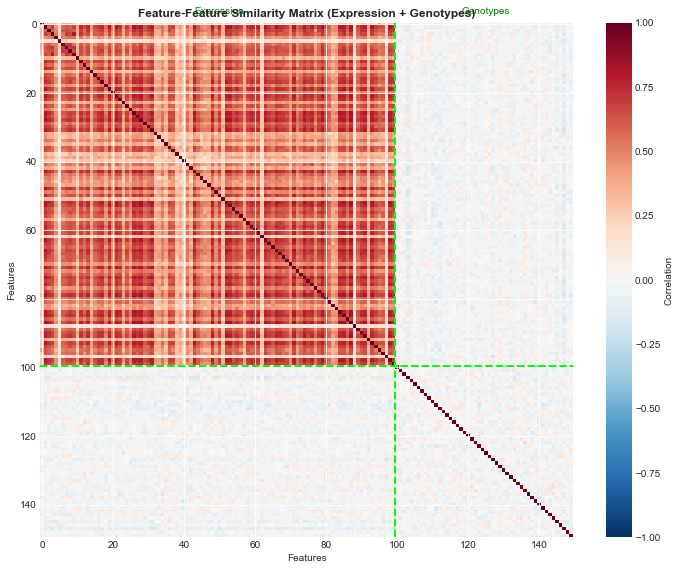

In [6]:
# =============================================================================
# COMPUTE FEATURE-FEATURE CORRELATION (SIMILARITY)
# =============================================================================
print("Computing Similarity Matrix")
print("="*50)

# Pearson correlation between all features
S = combined_data.corr(method='pearson')

print(f"Similarity matrix shape: {S.shape}")
print(f"Correlation range: [{S.min().min():.3f}, {S.max().max():.3f}]")

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(S, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_title('Feature-Feature Similarity Matrix (Expression + Genotypes)', fontweight='bold')
ax.set_xlabel('Features')
ax.set_ylabel('Features')
plt.colorbar(im, label='Correlation')

# Mark boundary between expression and genotype features
n_expr = len([c for c in combined_data.columns if c.startswith('expr_')])
ax.axhline(y=n_expr-0.5, color='lime', linewidth=2, linestyle='--')
ax.axvline(x=n_expr-0.5, color='lime', linewidth=2, linestyle='--')
ax.text(n_expr/2, -3, 'Expression', ha='center', fontsize=10, color='green')
ax.text(n_expr + (S.shape[0]-n_expr)/2, -3, 'Genotypes', ha='center', fontsize=10, color='green')

plt.tight_layout()
plt.show()

---
## Step 4: Choose Soft-Thresholding Power (beta)

Find the power that achieves scale-free topology (R^2 >= 0.8).

Selecting Soft-Thresholding Power
Found power with R^2 >= 0.8
Selected power: beta = 4
R-squared at selected power: 1.000


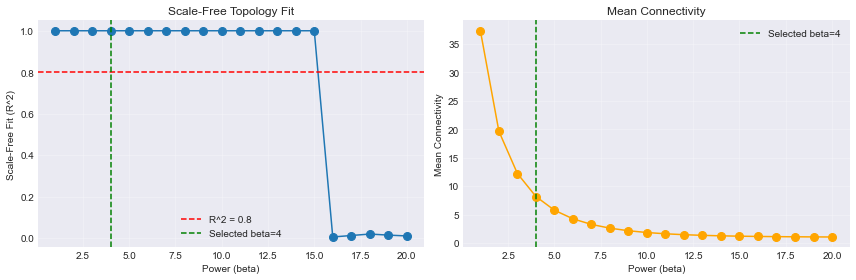

In [7]:
# =============================================================================
# SOFT-THRESHOLDING POWER SELECTION
# =============================================================================
print("Selecting Soft-Thresholding Power")
print("="*50)

powers = range(1, 21)
results = []

for beta in powers:
    # Adjacency = |correlation|^beta
    A = np.abs(S.values) ** beta
    
    # Connectivity (sum of connections per node)
    k = A.sum(axis=1)
    
    # Scale-free fit: linear regression of log(P(k)) vs log(k)
    k_unique, k_counts = np.unique(k[k > 0], return_counts=True)
    # Need at least 3 unique values for meaningful fit
    if len(k_unique) >= 3:
        log_k = np.log10(k_unique).reshape(-1, 1)
        log_pk = np.log10(k_counts)
        model = LinearRegression().fit(log_k, log_pk)
        r_sq = model.score(log_k, log_pk)
    else:
        r_sq = 0  # Not enough points for meaningful fit
    
    results.append({'Power': beta, 'R_squared': r_sq, 'Mean_k': k.mean()})

sft_df = pd.DataFrame(results)

# Select power: first >= 4 with R^2 >= 0.8, or default to 6
# Minimum power of 4 ensures sparse enough network for module detection
good_powers = sft_df[(sft_df['R_squared'] >= 0.8) & (sft_df['Power'] >= 4)]
if len(good_powers) > 0:
    beta_optimal = int(good_powers.iloc[0]['Power'])
    print(f"Found power with R^2 >= 0.8")
else:
    # Default power of 6 is recommended for unsigned networks
    beta_optimal = 6
    print(f"Using default power=6 (standard for unsigned networks)")

print(f"Selected power: beta = {beta_optimal}")
print(f"R-squared at selected power: {sft_df[sft_df['Power']==beta_optimal]['R_squared'].values[0]:.3f}")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(sft_df['Power'], sft_df['R_squared'], 'o-', markersize=8)
ax1.axhline(y=0.8, color='red', linestyle='--', label='R^2 = 0.8')
ax1.axvline(x=beta_optimal, color='green', linestyle='--', label=f'Selected beta={beta_optimal}')
ax1.set_xlabel('Power (beta)')
ax1.set_ylabel('Scale-Free Fit (R^2)')
ax1.set_title('Scale-Free Topology Fit')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(sft_df['Power'], sft_df['Mean_k'], 'o-', color='orange', markersize=8)
ax2.axvline(x=beta_optimal, color='green', linestyle='--', label=f'Selected beta={beta_optimal}')
ax2.set_xlabel('Power (beta)')
ax2.set_ylabel('Mean Connectivity')
ax2.set_title('Mean Connectivity')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 5: Build Adjacency and TOM Matrices

In [8]:
# =============================================================================
# ADJACENCY MATRIX: A = |S|^beta
# =============================================================================
print(f"Building Adjacency Matrix (beta={beta_optimal})")
print("="*50)

A = pd.DataFrame(
    np.abs(S.values) ** beta_optimal,
    index=S.index,
    columns=S.columns
)

print(f"Adjacency matrix shape: {A.shape}")
print(f"Adjacency range: [{A.min().min():.6f}, {A.max().max():.6f}]")

Building Adjacency Matrix (beta=4)
Adjacency matrix shape: (150, 150)
Adjacency range: [0.000000, 1.000000]


In [9]:
# =============================================================================
# TOPOLOGICAL OVERLAP MATRIX (TOM)
# TOM measures shared neighbors between features
# Formula: TOM[i,j] = (L[i,j] + A[i,j]) / (min(k[i], k[j]) + 1 - A[i,j])
# =============================================================================
print("Computing Topological Overlap Matrix (TOM)")
print("="*50)

A_np = A.values
n = A_np.shape[0]

# Connectivity per node
k = A_np.sum(axis=1)

# Shared neighbors: L = A @ A
L = A_np @ A_np

# Compute TOM
TOM = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i == j:
            TOM[i, j] = 1.0
        else:
            numerator = L[i, j] + A_np[i, j]
            denominator = min(k[i], k[j]) + 1 - A_np[i, j]
            TOM[i, j] = numerator / denominator if denominator > 0 else 0

TOM = pd.DataFrame(TOM, index=A.index, columns=A.columns)
print(f"TOM computed: shape {TOM.shape}")

# TOM dissimilarity for clustering
dissTOM = 1 - TOM
print(f"TOM dissimilarity computed")

Computing Topological Overlap Matrix (TOM)
TOM computed: shape (150, 150)
TOM dissimilarity computed


---
## Step 6: Hierarchical Clustering and Module Identification

In [10]:
# =============================================================================
# HIERARCHICAL CLUSTERING
# =============================================================================
print("Performing Hierarchical Clustering")
print("="*50)

# Convert to condensed distance matrix
dissTOM_condensed = squareform(dissTOM, checks=False)

# Cluster using average linkage
tree = linkage(dissTOM_condensed, method='average')

print(f"Clustering complete: {len(dissTOM.columns)} features")

Performing Hierarchical Clustering
Clustering complete: 150 features


In [11]:
# =============================================================================
# IDENTIFY MODULES BY CUTTING TREE
# =============================================================================
print("Identifying Modules")
print("="*50)

# Parameters
# Use maxclust criterion to get a target number of modules for better visualization
n_target_modules = 5  # Target number of clusters for this dataset

# Method 1: Try distance-based cutting first
tree_heights = tree[:, 2]
print(f"Tree height range: {tree_heights.min():.3f} to {tree_heights.max():.3f}")

# Use maxclust to get target number of modules
labels_initial = fcluster(tree, t=n_target_modules, criterion='maxclust')

print(f"Clusters from maxclust: {len(np.unique(labels_initial))}")

# No filtering needed with maxclust - just use directly
min_module_size = 1  # Keep all clusters

# Create assignment table
module_colors = ['grey', 'turquoise', 'blue', 'brown', 'yellow', 'green', 
                 'red', 'black', 'pink', 'magenta', 'purple', 'orange']

module_assignment = pd.DataFrame({
    'Feature': dissTOM.columns.tolist(),
    'ModuleNum': labels_initial,  # Use labels directly (1-indexed)
    'ModuleColor': [module_colors[i % len(module_colors)] for i in labels_initial],
    'Type': ['Expression' if c.startswith('expr_') else 'Genotype' for c in dissTOM.columns]
})

print(f"\nModules identified: {module_assignment['ModuleNum'].max()}")
print(f"\nModule composition:")
for mod in sorted(module_assignment['ModuleNum'].unique()):
    subset = module_assignment[module_assignment['ModuleNum'] == mod]
    n_expr = (subset['Type'] == 'Expression').sum()
    n_geno = (subset['Type'] == 'Genotype').sum()
    color = subset['ModuleColor'].iloc[0]
    print(f"  Module {mod} ({color}): {len(subset)} features ({n_expr} expr, {n_geno} geno)")

Identifying Modules
Tree height range: 0.622 to 1.000
Clusters from maxclust: 5

Modules identified: 5

Module composition:
  Module 1 (turquoise): 2 features (0 expr, 2 geno)
  Module 2 (blue): 3 features (0 expr, 3 geno)
  Module 3 (brown): 143 features (100 expr, 43 geno)
  Module 4 (yellow): 1 features (0 expr, 1 geno)
  Module 5 (green): 1 features (0 expr, 1 geno)


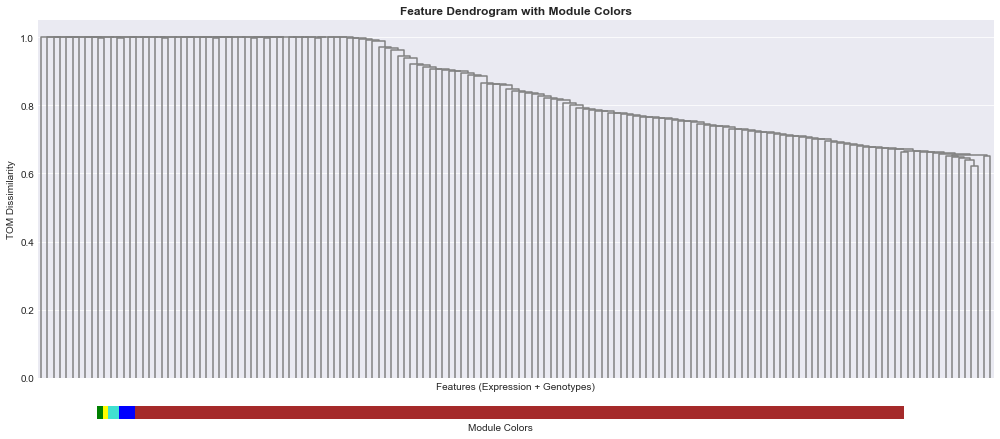

In [12]:
# =============================================================================
# VISUALIZE DENDROGRAM WITH MODULE COLORS
# =============================================================================
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(14, 6))

# Plot dendrogram (no color_threshold since we used maxclust)
dendro = dendrogram(
    tree,
    labels=dissTOM.columns.tolist(),
    ax=ax,
    color_threshold=0,  # Color all branches
    above_threshold_color='gray',
    no_labels=True
)

ax.set_title('Feature Dendrogram with Module Colors', fontsize=12, fontweight='bold')
ax.set_xlabel('Features (Expression + Genotypes)')
ax.set_ylabel('TOM Dissimilarity')

# Add color bar for modules
ax2 = fig.add_axes([0.1, 0.02, 0.8, 0.03])
feature_order = [dissTOM.columns[i] for i in dendro['leaves']]
colors_ordered = [module_assignment[module_assignment['Feature'] == f]['ModuleColor'].iloc[0] for f in feature_order]

for idx, col in enumerate(colors_ordered):
    try:
        rgb = mcolors.to_rgb(col)
    except:
        rgb = (0.5, 0.5, 0.5)
    ax2.add_patch(Rectangle((idx, 0), 1, 1, facecolor=rgb, edgecolor='none'))

ax2.set_xlim(0, len(colors_ordered))
ax2.set_ylim(0, 1)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xlabel('Module Colors')

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

---
## Step 7: Calculate Module Eigengenes

Module eigengene = First principal component of features in each module.

In [13]:
# =============================================================================
# MODULE EIGENGENES
# =============================================================================
print("Computing Module Eigengenes")
print("="*50)

ME_dict = {}

for mod in sorted(module_assignment['ModuleNum'].unique()):
    if mod == 0:  # Skip grey (unassigned)
        continue
    
    # Get features in this module
    features = module_assignment[module_assignment['ModuleNum'] == mod]['Feature'].tolist()
    color = module_assignment[module_assignment['ModuleNum'] == mod]['ModuleColor'].iloc[0]
    
    # Get data for these features
    module_data = combined_data[features]
    
    if len(features) == 1:
        # Single feature module
        ME_dict[f'ME{mod}'] = module_data.iloc[:, 0].values
    else:
        # PCA to get first principal component
        pca = PCA(n_components=1)
        ME_dict[f'ME{mod}'] = pca.fit_transform(module_data).flatten()
        var_exp = pca.explained_variance_ratio_[0]
        print(f"  Module {mod} ({color}): {len(features)} features, PC1 variance = {var_exp:.1%}")

ME_df = pd.DataFrame(ME_dict, index=combined_data.index)
print(f"\nModule eigengenes computed: {ME_df.shape}")

Computing Module Eigengenes
  Module 1 (turquoise): 2 features, PC1 variance = 56.0%
  Module 2 (blue): 3 features, PC1 variance = 40.7%
  Module 3 (brown): 143 features, PC1 variance = 37.3%

Module eigengenes computed: (300, 5)


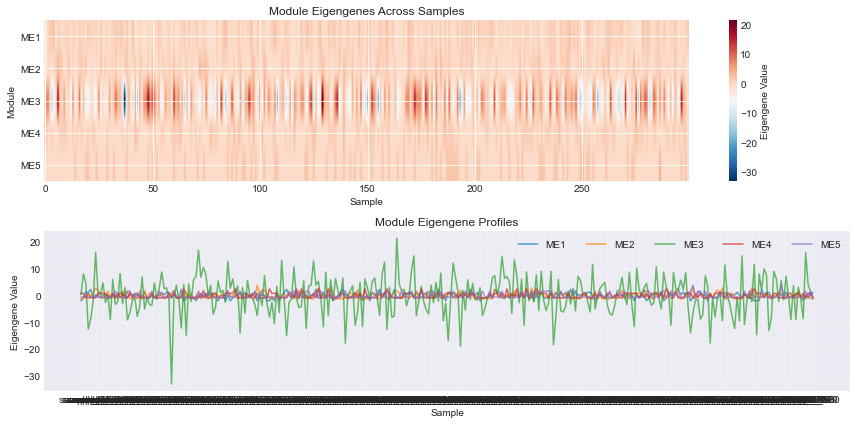

In [14]:
# =============================================================================
# VISUALIZE MODULE EIGENGENES
# =============================================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Heatmap
im = axes[0].imshow(ME_df.T, aspect='auto', cmap='RdBu_r')
axes[0].set_yticks(range(len(ME_df.columns)))
axes[0].set_yticklabels(ME_df.columns)
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Module')
axes[0].set_title('Module Eigengenes Across Samples')
plt.colorbar(im, ax=axes[0], label='Eigengene Value')

# Line plot
for col in ME_df.columns:
    axes[1].plot(ME_df[col], label=col, alpha=0.7)
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Eigengene Value')
axes[1].set_title('Module Eigengene Profiles')
axes[1].legend(loc='upper right', ncol=len(ME_df.columns))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 8: Relate Modules to Clinical Traits

In [15]:
# =============================================================================
# MODULE-TRAIT CORRELATIONS
# =============================================================================
print("Computing Module-Trait Correlations")
print("="*50)

# Traits of interest
traits = covariates[['ASD', 'Age', 'Sex', 'IQ', 'ADOS_Score']].copy()

# Compute correlations
corr_data = []
pval_data = []

for module in ME_df.columns:
    corr_row = {}
    pval_row = {}
    for trait in traits.columns:
        valid = ~traits[trait].isna()
        if valid.sum() > 0:
            r, p = stats.pearsonr(ME_df.loc[valid, module], traits.loc[valid, trait])
            corr_row[trait] = r
            pval_row[trait] = p
        else:
            corr_row[trait] = np.nan
            pval_row[trait] = np.nan
    corr_data.append(corr_row)
    pval_data.append(pval_row)

trait_corr = pd.DataFrame(corr_data, index=ME_df.columns)
trait_pval = pd.DataFrame(pval_data, index=ME_df.columns)

print("Module-Trait Correlations:")
print(trait_corr.round(3))

Computing Module-Trait Correlations
Module-Trait Correlations:
       ASD    Age    Sex     IQ  ADOS_Score
ME1 -0.044  0.148  0.024  0.069      -0.051
ME2  0.180 -0.082  0.086 -0.187       0.179
ME3 -0.078  0.029  0.023 -0.012      -0.033
ME4  0.012 -0.007 -0.028  0.021       0.046
ME5 -0.058 -0.081 -0.051  0.008      -0.056


In [16]:
# =============================================================================
# GENETIC BURDEN ANALYSIS
# =============================================================================
print("\nGenetic Burden Analysis")
print("="*50)

# Genetic burden = sum of risk alleles per sample
genetic_burden = genotypes.sum(axis=1)
print(f"Genetic burden range: {genetic_burden.min()} to {genetic_burden.max()}")

# Correlate modules with genetic burden
burden_corr = []
for module in ME_df.columns:
    r, p = stats.pearsonr(ME_df[module], genetic_burden)
    burden_corr.append({'Module': module, 'Correlation': r, 'P-value': p})
    print(f"  {module}: r={r:.3f}, p={p:.4f}")

burden_corr_df = pd.DataFrame(burden_corr)


Genetic Burden Analysis
Genetic burden range: 9 to 38
  ME1: r=-0.060, p=0.2967
  ME2: r=0.254, p=0.0000
  ME3: r=-0.097, p=0.0934
  ME4: r=0.097, p=0.0932
  ME5: r=0.137, p=0.0177


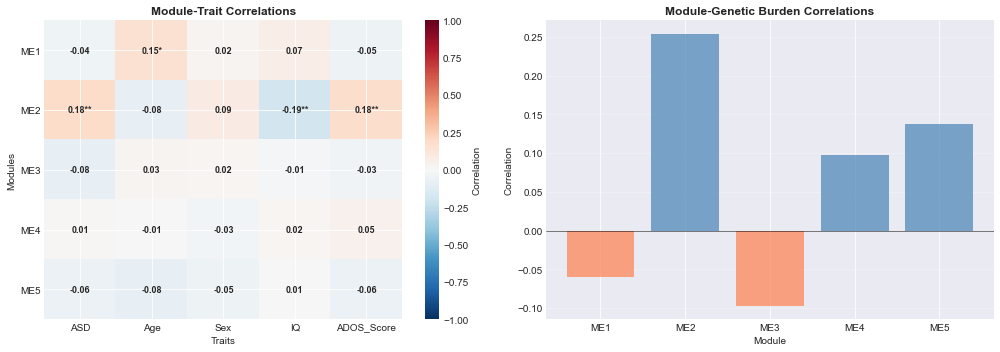

In [17]:
# =============================================================================
# VISUALIZE MODULE-TRAIT RELATIONSHIPS
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
ax = axes[0]
im = ax.imshow(trait_corr.astype(float), cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_yticks(range(len(trait_corr.index)))
ax.set_xticks(range(len(trait_corr.columns)))
ax.set_yticklabels(trait_corr.index)
ax.set_xticklabels(trait_corr.columns)
ax.set_title('Module-Trait Correlations', fontweight='bold')
ax.set_xlabel('Traits')
ax.set_ylabel('Modules')

# Add values with significance stars
for i in range(len(trait_corr.index)):
    for j in range(len(trait_corr.columns)):
        r = trait_corr.iloc[i, j]
        p = trait_pval.iloc[i, j]
        if pd.notna(p):
            stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            ax.text(j, i, f'{r:.2f}{stars}', ha='center', va='center', fontsize=9, fontweight='bold')

plt.colorbar(im, ax=ax, label='Correlation')

# Genetic burden bar plot
ax = axes[1]
colors = ['steelblue' if r > 0 else 'coral' for r in burden_corr_df['Correlation']]
ax.bar(burden_corr_df['Module'], burden_corr_df['Correlation'], color=colors, alpha=0.7)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Module')
ax.set_ylabel('Correlation')
ax.set_title('Module-Genetic Burden Correlations', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/ASD_dataset/WGCNA_multiomics_results.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Summary: Multi-Omics WGCNA Results

In [18]:
# =============================================================================
# SUMMARY
# =============================================================================
print("="*80)
print("MULTI-OMICS WGCNA ANALYSIS COMPLETE")
print("="*80)

print(f"\nDataset:")
print(f"  Samples: {combined_data.shape[0]}")
print(f"  Expression features: {len([c for c in combined_data.columns if c.startswith('expr_')])}")
print(f"  Genotype features: {len([c for c in combined_data.columns if c.startswith('geno_')])}")
print(f"  Total features: {combined_data.shape[1]}")

print(f"\nWGCNA Parameters:")
print(f"  Soft-thresholding power: {beta_optimal}")
print(f"  Number of modules: {n_target_modules}")

print(f"\nModules Identified: {module_assignment['ModuleNum'].max()}")
for mod in sorted(module_assignment['ModuleNum'].unique()):
    subset = module_assignment[module_assignment['ModuleNum'] == mod]
    n_expr = (subset['Type'] == 'Expression').sum()
    n_geno = (subset['Type'] == 'Genotype').sum()
    color = subset['ModuleColor'].iloc[0]
    print(f"  Module {mod} ({color}): {len(subset)} features ({n_expr} expr, {n_geno} geno)")

print(f"\nSignificant Module-Trait Associations (p < 0.05):")
found = False
for trait in trait_corr.columns:
    for module in trait_corr.index:
        r = trait_corr.loc[module, trait]
        p = trait_pval.loc[module, trait]
        if pd.notna(p) and p < 0.05:
            print(f"  {module} ~ {trait}: r={r:.3f}, p={p:.4f}")
            found = True
if not found:
    print("  No significant associations (p < 0.05)")

print(f"\nOutput saved: ../data/ASD_dataset/WGCNA_multiomics_results.png")

MULTI-OMICS WGCNA ANALYSIS COMPLETE

Dataset:
  Samples: 300
  Expression features: 100
  Genotype features: 50
  Total features: 150

WGCNA Parameters:
  Soft-thresholding power: 4
  Number of modules: 5

Modules Identified: 5
  Module 1 (turquoise): 2 features (0 expr, 2 geno)
  Module 2 (blue): 3 features (0 expr, 3 geno)
  Module 3 (brown): 143 features (100 expr, 43 geno)
  Module 4 (yellow): 1 features (0 expr, 1 geno)
  Module 5 (green): 1 features (0 expr, 1 geno)

Significant Module-Trait Associations (p < 0.05):
  ME2 ~ ASD: r=0.180, p=0.0018
  ME1 ~ Age: r=0.148, p=0.0100
  ME2 ~ IQ: r=-0.187, p=0.0011
  ME2 ~ ADOS_Score: r=0.179, p=0.0019

Output saved: ../data/ASD_dataset/WGCNA_multiomics_results.png
